### Loading a small, built-in dataset (e.g., Iris dataset)

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# The dataset is returned as a Bunch object, which is like a dictionary.
# It contains:
# - 'data': the features
# - 'target': the labels
# - 'feature_names': names of the features
# - 'target_names': names of the target classes
# - 'DESCR': a description of the dataset

print("Keys of iris dataset:\n{}".format(iris.keys()))
print("\nShape of data: {}".format(iris.data.shape))
print("\nFirst 5 rows of data:\n{}".format(iris.data[:5]))
print("\nTarget names: {}".format(iris.target_names))

# You can also create a pandas DataFrame for easier viewing
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
display(iris_df.head())

Keys of iris dataset:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Shape of data: (150, 4)

First 5 rows of data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Scikit-learn offers many other datasets, including `load_breast_cancer`, `load_diabetes`, `load_digits`, `load_linnerud`, `load_wine`, and more fetched datasets like `fetch_california_housing`, `fetch_lfw_people`, etc. You can find a complete list in the [scikit-learn documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html).

Scikit-learn offers many datasets, which can generally be categorized into two types:

### Small, built-in datasets (loaded with `load_` functions):
*   `load_iris()`: The classic Iris flower dataset.
*   `load_breast_cancer()`: A dataset for breast cancer diagnosis.
*   `load_digits()`: A dataset of handwritten digits.
*   `load_diabetes()`: A dataset for diabetes progression.
*   `load_wine()`: A dataset for wine classification.
*   `load_linnerud()`: A multi-output regression dataset.

### Larger datasets that require downloading (loaded with `fetch_` functions):
*   `fetch_olivetti_faces()`: A dataset of facial images.
*   `fetch_20newsgroups()`: A dataset of newsgroup documents.
*   `fetch_california_housing()`: A dataset for house prices in California.
*   `fetch_lfw_people()`: Labeled Faces in the Wild dataset.
*   `fetch_rcv1()`: Reuters Corpus Volume I dataset.
*   `fetch_openml()`: Allows fetching datasets from the OpenML platform.

For a complete and up-to-date list, you can always refer to the official [scikit-learn documentation on datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html).

In [2]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
X.shape, y.shape

((150, 4), (150,))

In [5]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [6]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 1.0


### 1. K-fold cross validation

- **Definition:** K-fold cross-validation is a robust technique for evaluating machine learning models by partitioning the original dataset into k subsets (folds).
- **Process:** The model is trained k times. Each time, one fold is used as the test set, and the remaining k-1 folds are used as the training set.
- **Evaluation:** The performance metric (e.g., accuracy, precision) is computed for each of the k test sets. The final model performance is then the average of these k scores.
- **Benefit 1 (Reduced Bias):** It helps reduce bias by ensuring that every data point gets to be in the test set exactly once and is used for training k-1 times, leading to a more reliable estimate of model performance on unseen data.
- **Benefit 2 (Better Data Utilization):** Compared to a simple train-test split, it makes better use of the available data, especially with smaller datasets, as all data points contribute to both training and testing.

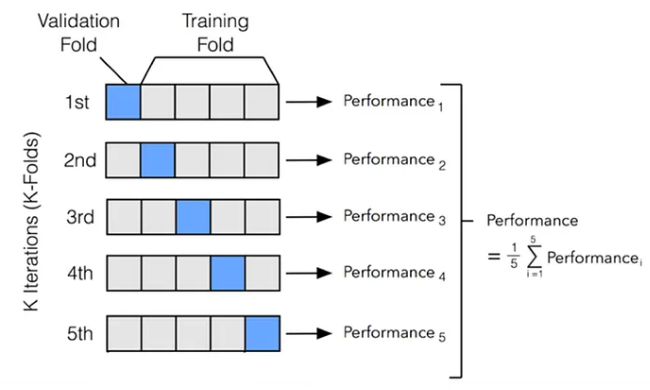

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lor = LogisticRegression()
model_lor.fit(X_train, y_train)
y_pred = model_lor.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [34]:
from sklearn.model_selection import KFold
# create an instance of the KFold cross-validator
kf = KFold(n_splits=10,random_state=20,shuffle=True)
kf

KFold(n_splits=10, random_state=20, shuffle=True)

In [35]:
dir(kf)

['_BaseCrossValidator__metadata_request__split',
 '__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_get_default_requests',
 '_get_metadata_request',
 '_iter_test_indices',
 '_iter_test_masks',
 'get_metadata_routing',
 'get_n_splits',
 'n_splits',
 'random_state',
 'shuffle',
 'split']

In [ ]:
(array([ 15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149]), array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]))

In [ ]:
for i in kf.split(X):
  print(i)

In [31]:
# create lists to store the accuracy scores for each fold
accuracies = []

# iterate over the splits
for train_index, test_index in kf.split(X):
    # split the data into training and test sets
    X_train, X_test = X[train_index], X[test_index]
    #print(X_train, X_test)
    y_train, y_test = y[train_index], y[test_index]

    # fit the model on the training data
    model_lor.fit(X_train, y_train)

    # make predictions on the test data
    y_pred = model_lor.predict(X_test)

    # calculate the accuracy of the model
    accuracy = accuracy_score(y_test, y_pred)

    # append the accuracy score to the list
    accuracies.append(accuracy)
    print(accuracy)
# calculate the average accuracy across all folds
average_accuracy = sum(accuracies) / len(accuracies)
import numpy as np
average_accuracy = np.mean(average_accuracy)
var = np.var(average_accuracy)

# print the average accuracy
print("Average accuracy:", average_accuracy)
print("Varience",var)
print("Std",np.std(average_accuracy))

0.9333333333333333
1.0
0.9333333333333333
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

1.0
1.0
0.9333333333333333
1.0
0.8666666666666667
1.0
Average accuracy: 0.9666666666666666
Varience 0.0
Std 0.0


In [32]:
# using sklearn
from sklearn.model_selection import cross_val_score
score = cross_val_score(model_lor, X, y, cv=kf)
print("Score is", score)
print("average score is", score.mean())
print("len of Score is", len(score))

Score is [0.93333333 1.         0.93333333 1.         1.         1.
 0.93333333 1.         0.86666667 1.        ]
average score is 0.9666666666666668
len of Score is 10


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [21]:
score.var()

np.float64(0.0010666666666666663)

### 2. Stratified k-fold cross validation

- **Definition:** Stratified k-fold cross-validation is a variation of k-fold cross-validation that ensures each fold maintains the same proportion of samples from each target class as the complete dataset.
- **Purpose:** Its primary purpose is to address issues that arise in imbalanced datasets, where some classes are significantly underrepresented. A simple k-fold split might result in some folds having very few or even zero samples of a minority class.
- **Process:** Before splitting, the data is grouped by its target labels. Then, each group is split into k folds, ensuring that each fold gets a representative sample from each class. These k stratified folds are then used for training and testing, just like in standard k-fold.


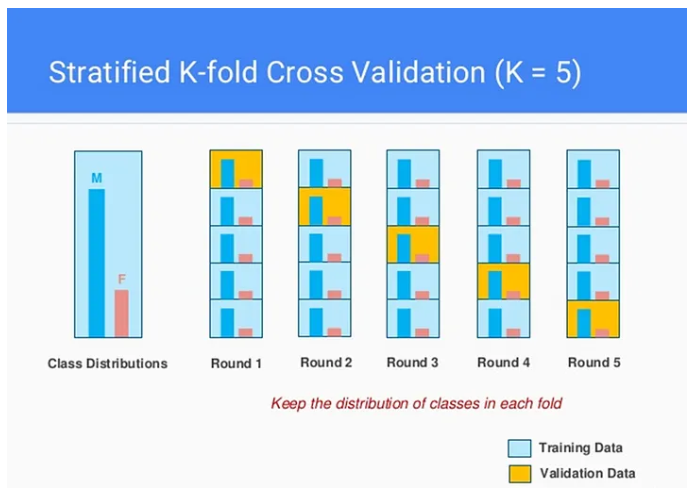

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
st_cv = StratifiedKFold(n_splits=5)
cv_score = cross_val_score(model_lor,X,y,cv=st_cv)
print(cv_score.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9733333333333334


3. Leave-One-Out (LOO):
- Leave-One-Out (LOO) cross-validation is a method of cross-validation where we use n-1 samples of the dataset as the training set and 1 sample as the test set, where n is the total number of samples in the dataset. This process is repeated n times, each time leaving out a different sample as the test set. This method is an exhaustive technique.

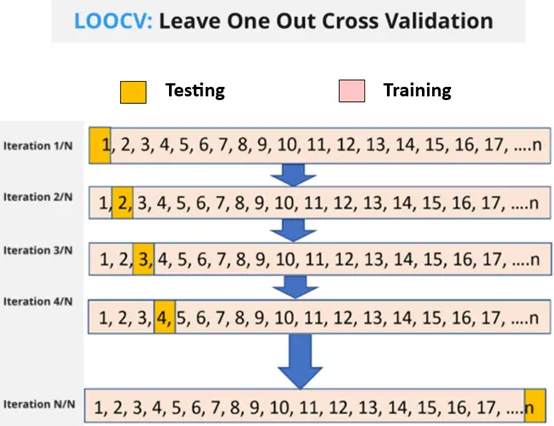

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(clf, X, y, cv = loo)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Average CV Score:  0.94
Number of CV Scores used in Average:  150


### 4. Leave-P-Out (LPO):

In [ ]:
from sklearn.model_selection import LeavePOut
lpo = LeavePOut(p=2)
scores = cross_val_score(clf, X, y, cv = lpo)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

### 5. Repeated k-Fold cross-validation:

In [33]:
from sklearn.model_selection import RepeatedKFold
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_val_score(model_lor, X, y, cv=rkf)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Scores:  [1.         1.         0.93333333 0.96666667 0.96666667 0.96666667
 1.         0.93333333 1.         0.93333333 0.96666667 0.9
 1.         1.         0.96666667 0.93333333 1.         0.9
 0.96666667 1.         0.93333333 0.96666667 1.         0.93333333
 0.96666667]
Average CV Score:  0.9653333333333333
Number of CV Scores used in Average:  25


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
X.shape

(150, 4)